# **Customer Support Agent With LangGraph**

Create an Intelligent customer support agent. using LangGraph, a powerful tool for building tool for building comple language model workflows.

The agent is designed to categorize customer queries, analyze sentiment, and provide appropriate responses or escalate issues when necessary.

- State Management : Using TypedDict to define and manage the state of each customer interaction.
- Query Categorization : Classifying customer queries into Technical, Billing, or General Categories.
- Sentiment Analysis: Determining the emotional tone of customer queries.
- Response Generation: Creating appropriate responses based on the query category and sentiment.
- Escalation Mechanism: Automatically escalating queries with negative sentiment to human agents.
- Workflow Graph: Utilizing LangGraph to create a flexible and extensible workflow.

In [1]:
!pip install -q langchain langchain-core langchain-community python-dotenv ipython langchain_huggingface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate

from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod
import os


In [3]:
from google.colab import userdata
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

HF_TOKEN = userdata.get("HF_TOKEN_1")

llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen3-8B",
    huggingfacehub_api_token=HF_TOKEN,
    task="conversational",
    max_new_tokens=512,
    temperature=0.2,
)

llm = ChatHuggingFace(llm=llm)


State Class to hold the query, category, sentiment, and response for each customer interaction.

In [4]:
class State(TypedDict):
  query: str
  category: str
  sentiment: str
  response: str

In [24]:
def categorize(state: State)-> State:
  """Categorize the customer Query into Technical, billing, or General """
  prompt = ChatPromptTemplate.from_template(
      'Categorize the following customer query into one of these categorise:'
      'Technical, Billing, General. Query:{query}'
  )

  chain = prompt | llm
  category = chain.invoke({'query': state['query']}).content
  return {'category':category}

In [25]:
def analyze_sentiment(state: State)-> State:
  """Analyze the sentiment of the following customer query as Positive, Neutral, or Negative"""
  prompt = ChatPromptTemplate.from_template(
      "Analyze the sentiment of the following customer query as Positive, Neutral, or Negative"
      "Respond with either 'Positive','Neutral', or 'Negative'. Query:{query}"
  )

  chain = prompt | llm
  sentiment = chain.invoke({'query': state['query']}).content
  return {'sentiment': sentiment}

In [26]:
def handle_technical(state: State)-> State:
  """Provide a technical Support response to the query."""
  prompt = ChatPromptTemplate.from_template(
      "Provide a technical support response to the following query: {query}"
  )

  chain = prompt | llm
  response = chain.invoke({'query':state['query']}).content
  return {'response':response}

In [27]:
def handle_billing(state: State) ->State:
  """Provide a billing support response to the query."""
  prompt = ChatPromptTemplate.from_template(
      "provide a billing support response to the following query: {query}"
  )

  chain = prompt | llm
  response = chain.invoke({'query':state['query']}).content
  return {"response": response}

In [28]:
def handle_general(state: State)-> State:
  """Provide a general support response to the query"""
  prompt = ChatPromptTemplate.from_template(
      "Provide a general support response to the following query: {query}"
  )
  chain = prompt | llm
  response = chain.invoke({"query": state["query"]}).content
  return {"response" : response}

In [29]:
def escalate(state: State)-> State:
  """Escalate the query to a human agent due to negative sentiment."""
  return {"response": "This query has been escalated to a human agent due to its negative sentiment."}


In [30]:
def route_query(state: State)-> str:
  """Route the query based on its sentiment and category"""
  if state['sentiment'] == "Negative":
    return "escalate"
  elif state['category'] == "Technical":
    return "handle_technical"
  elif state['category'] == "Billing":
    return "handle_billing"
  else:
    return "handle_general"

In [31]:
# Create the graph
workflow = StateGraph(State)

# Add Nodes
workflow.add_node("categorize",categorize)
workflow.add_node("analyze_sentiment", analyze_sentiment)
workflow.add_node("handle_technical", handle_technical)
workflow.add_node("handle_billing", handle_billing)
workflow.add_node("handle_general", handle_general)
workflow.add_node("escalate", escalate)

# Add Edges
workflow.add_edge("categorize", "analyze_sentiment")
workflow.add_conditional_edges(
    "analyze_sentiment", route_query,
    {
        "handle_technical":"handle_technical",
        "handle_billing": "handle_billing",
        "handle_general": "handle_general",
        "escalate": "escalate"
    }
)

workflow.add_edge("handle_technical", END)
workflow.add_edge("handle_billing", END)
workflow.add_edge("handle_general", END)
workflow.add_edge("escalate", END)

# Set Entry Point
workflow.set_entry_point("categorize")


In [32]:
app = workflow.compile()

# Visualization of Workflow

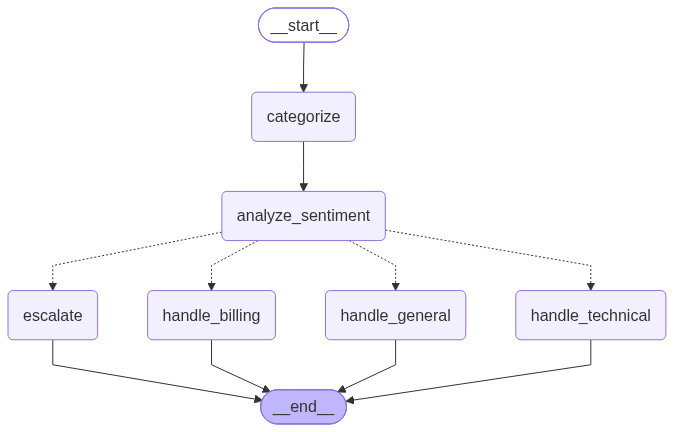

In [33]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [34]:
def run_customer_support(query: str) -> Dict[str,str]:
  """Process a customer query through the LangGraph Workflow.

  Args: query(str): The customer's query

  Returns: Dict[str, str]: A dictionary containing the query's category, sentiment
  and response

  """

  results = app.invoke({"query":query})
  return {
      "category": results["category"],
      "sentiment": results["sentiment"],
      "response": results["response"]
  }

In [35]:
# escalte
query = "My internet connection keeps dropping. Can you help?"
result = run_customer_support(query)
print(f"Query: {query}")
print(f"Category: {result['category']}")
print(f"Sentiment: {result['sentiment']}")
print(f"Response: {result['response']}")
print("\n")



Query: My internet connection keeps dropping. Can you help?
Category: 

The query "My internet connection keeps dropping. Can you help?" should be categorized as **Technical**. This is because the issue pertains to the functionality and performance of the internet service, which falls under technical support.
Sentiment: 

Negative
Response: 

Certainly! Here's a general support response to your query:

---

**Troubleshooting Tips for a Dropping Internet Connection:**

1. **Check Physical Connections:**  
   - Ensure all cables (Ethernet, power) are securely connected to your router, modem, and devices.  
   - If using Wi-Fi, try moving closer to the router or reducing interference from walls, appliances, or other devices.

2. **Restart Your Equipment:**  
   - Power cycle your router and modem by unplugging them for 30 seconds, then plugging them back in.  
   - Restart your devices (phone, laptop, etc.) to refresh the connection.

3. **Check for Interference:**  
   - Avoid placing yo

In [40]:
# handle_technical
query = "I need help talking to ChatGPT"
result = run_customer_support(query)
print(f"Query: {query}")
print(f"Category: {result['category']}")
print(f"Sentiment: {result['sentiment']}")
print(f"Response: {result['response']}")
print("\n")




Query: I need help talking to ChatGPT
Category: 

The query "I need help talking to ChatGPT" falls under the **Technical** category. This is because the user is seeking assistance with the functionality or interaction process of ChatGPT, which relates to its technical operation, troubleshooting, or usage. 

**Answer:** Technical
Sentiment: 

Neutral
Response: 

Certainly! If you're looking for help communicating effectively with ChatGPT or any AI model, here are some general tips to guide your interaction:  

1. **Be Clear and Specific**: Clearly state your question or request. Avoid vague phrasing (e.g., "Tell me about AI") and instead focus on a particular topic or goal (e.g., "Explain how machine learning works in simple terms").  

2. **Provide Context**: Share relevant background information to help the model understand your needs better. For example, if you're asking about a technical topic, mention your current knowledge level or what you’ve already tried.  

3. **Ask Open-Ended

In [41]:
# handle_billing
query = "where can i find my receipt?"
result = run_customer_support(query)
print(f"Query: {query}")
print(f"Category: {result['category']}")
print(f"Sentiment: {result['sentiment']}")
print(f"Response: {result["response"]}")
print("\n")


Query: where can i find my receipt?
Category: 

The query "where can I find my receipt?" falls under the **Billing** category. This is because receipts are directly related to transactions, payments, and invoice management, which are core aspects of billing processes.
Sentiment: 

Neutral
Response: 

If you're looking for your receipt, here are several places to check:  

1. **Physical Receipt**:  
   - Check your wallet, purse, or bag where you typically keep receipts.  
   - Look in the mailbox or email inbox (some businesses send digital copies).  

2. **Digital Receipts**:  
   - Check your phone’s email or messaging apps (e.g., SMS, WhatsApp, or email accounts).  
   - Review your account on the retailer’s website or app (e.g., Amazon, Starbucks, or grocery delivery services).  

3. **Payment Platforms**:  
   - Check your credit card or debit card statements for transaction details.  
   - Use services like PayPal, Venmo, or Apple/Google Pay, which often store receipt information

In [42]:
# Handle_general
query = "What are your business hours"
result = run_customer_support(query)
print(f"Query:{query}")
print(f"Category: {result['category']}")
print(f"Sentiment: {result['sentiment']}")
print(f"Response: {result['response']}")

Query:What are your business hours
Category: 

The query "What are your business hours?" falls under the **General** category. It pertains to operational information rather than technical support or billing-related inquiries.
Sentiment: 

Neutral
Response: 

Our business hours are typically Monday through Friday, from 9:00 AM to 5:00 PM, excluding public holidays. However, for the most accurate and up-to-date information, we recommend checking our official website or contacting our support team directly. If you need assistance outside of these hours, our team is available via email or live chat during extended support times. Let us know how we can help!


In [45]:
query = "What is machine learning?"
result = run_customer_support(query)
print(f"Query:{query}")
print(f"Category: {result['category']}")
print(f"Sentiment: {result['sentiment']}")
print(f"Response: {result['response']}")

Query:What is machine learning?
Category: 

The query "What is machine learning?" falls under the **General** category. It seeks an explanation of a concept rather than addressing technical troubleshooting, billing issues, or specific product-related questions.
Sentiment: 

Neutral
Response: 

Machine learning is a branch of artificial intelligence that focuses on developing algorithms and models that enable systems to learn patterns and make decisions from data without being explicitly programmed for specific tasks. Instead of following rigid instructions, these systems improve their performance over time by analyzing large datasets, identifying trends, and adjusting their approach based on experience. 

Common applications include image recognition, natural language processing, recommendation systems, and predictive analytics. Machine learning is broadly categorized into types like supervised learning (where models learn from labeled data), unsupervised learning (for discovering hidd